# Deep CNN for Cats vs Dogs

## Objective

Build and train a deep Convolutional Neural Network (CNN) using TensorFlow/Keras for binary image classification on the Cats vs Dogs dataset.

## Why a Deep CNN?

Unlike shallow neural networks, deep CNNs can learn hierarchical visual features, from simple edges and textures to more complex shapes and object representations. This makes them particularly effective for image classification tasks.

## Topics

- Cats vs Dogs dataset preprocessing
- Deep CNN architecture
- Convolutional layers
- Pooling layers
- Dropout regularization
- Model training
- Prediction
- Model evaluation

In [18]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import sys, os

from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sys.path.append(os.path.abspath(".."))
from utilities.utilities import *

In [19]:
train_images, train_labels, test_images, test_labels = load_cat_and_dog_data()

Loading cat images...
Loading dog images...
Creating train/test split...
Cats: 12501
Dogs: 12501


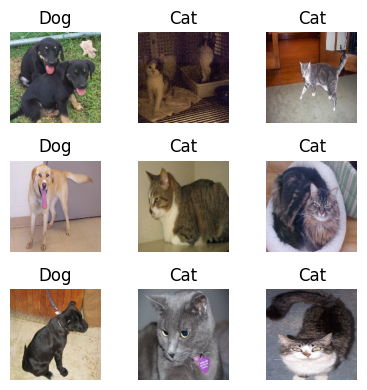

In [20]:
plt.figure(figsize=(4,4))

indices = np.random.choice(len(train_images), 9, replace=False)
for i, idx in enumerate(indices):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[idx].astype(np.uint8))
    plt.title("Dog" if train_labels[idx] else "Cat")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
def build_cnn(input_shape=(150,150,3),
              activation="relu",
              output_activation="sigmoid"):

    model = models.Sequential([
        # data_augmentation,
        # Layer 1
        keras.Input(input_shape),
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Layer 2
        layers.Conv2D(64, (3,3), activation=activation),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Layer 3
        layers.Conv2D(128, (3,3), activation=activation),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Fully Connected Layers
        layers.Flatten(),

        # Dense 1
        layers.Dense(256, activation=activation),
        layers.Dropout(0.5),

        # Dense 2 
        layers.Dense(128, activation=activation),
        layers.Dropout(0.5),

        # output
        layers.Dense(1, activation=output_activation)
    ])

    return model

In [22]:
train_images_cnn = train_images.astype("float32") / 255
test_images_cnn = test_images.astype("float32") / 255

train_labels_cnn = train_labels
test_labels_cnn = test_labels

In [23]:
def compile_and_train(model, optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]):
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    history = model.fit(
        train_images_cnn,
        train_labels_cnn,
        epochs=40,
        batch_size=50,
        validation_split=0.2
    )
    return history


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       9,470,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,597,377 (36.61 MB)

 Trainable params: 9,596,929 (36.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 48s 831ms/step - accuracy: 0.5555 - loss: 3.4157 - val_accuracy: 0.5203 - val_loss: 1.3001
Epoch 2/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 724ms/step - accuracy: 0.5453 - loss: 2.0643 - val_accuracy: 0.4703 - val_loss: 1.2941
Epoch 3/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 724ms/step - accuracy: 0.5559 - loss: 1.4289 - val_accuracy: 0.5031 - val_loss: 0.7648
Epoch 4/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 37s 718ms/step - accuracy: 0.5809 - loss: 0.9782 - val_accuracy: 0.5281 - val_loss: 0.7485
Epoch 5/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 37s 708ms/step - accuracy: 0.5809 - loss: 0.8491 - val_accuracy: 0.5562 - val_loss: 0.7163
Epoch 6/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 37s 710ms/step - accuracy: 0.5958 - loss: 0.8046 - val_accuracy: 0.5906 - val_loss: 0.6604
Epoch 7/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 729ms/step - accuracy: 0.6142 - loss: 0.7125 - val_accuracy: 0.5250 - val_loss: 0.6865
Epoch 8/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 722ms/step - accuracy: 0.6349 - loss: 0.6867 - val_accu

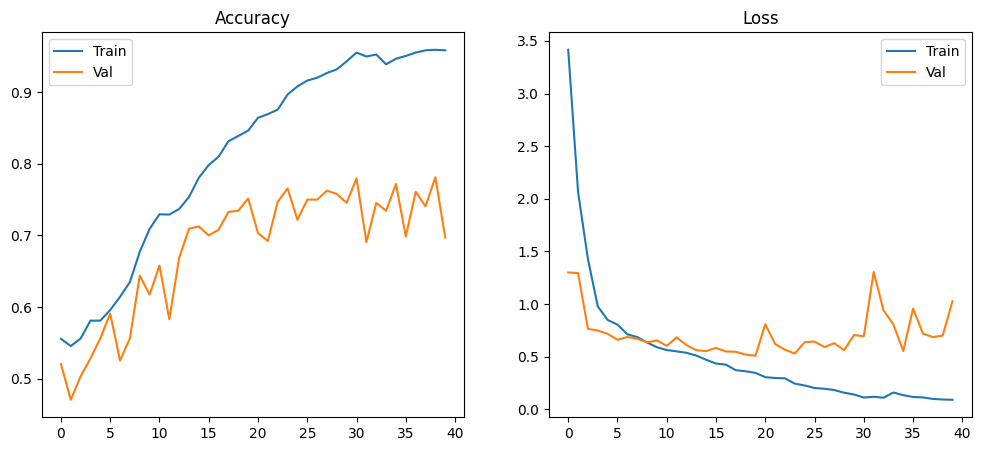

In [24]:
model_cnn = build_cnn()
model_cnn.summary()

history = compile_and_train(model_cnn)
plt.figure(figsize=(12, 5))

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(
    test_images_cnn,
    test_labels_cnn
)
print("Test accuracy:", test_acc_cnn * 100)


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

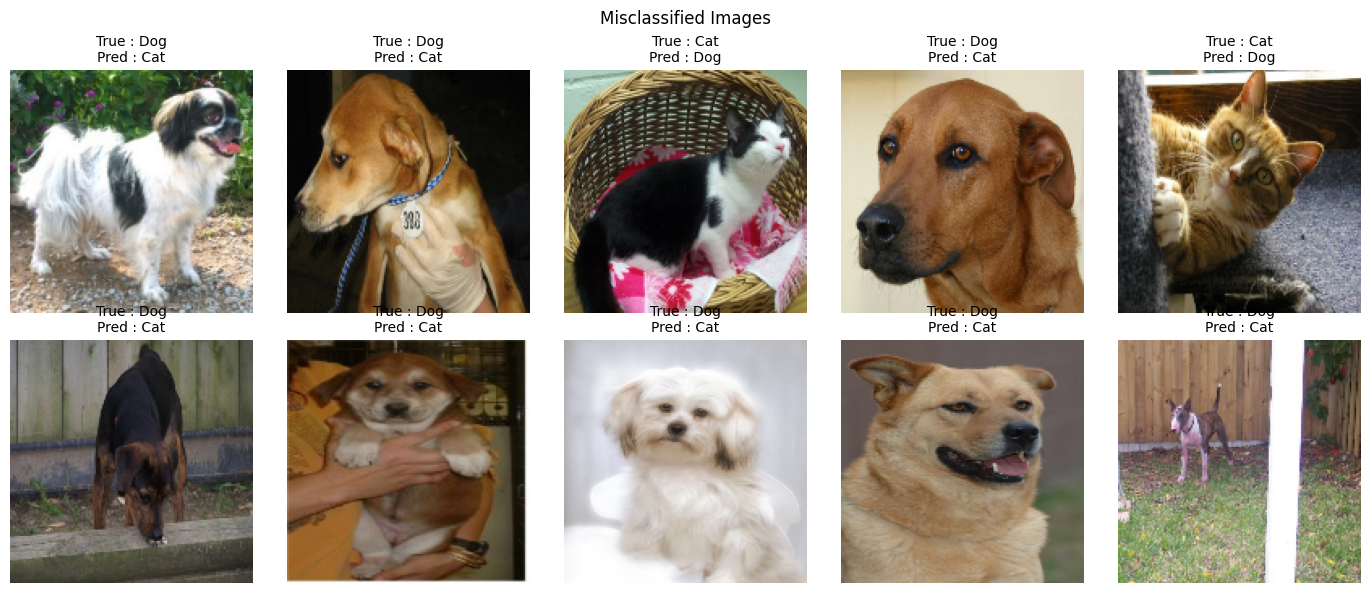

In [25]:
predictions = model_cnn.predict(test_images_cnn, verbose=0)
predicted_labels = (predictions > 0.5).astype(int).ravel()
misclassified_indices = np.where(predicted_labels != test_labels)[0]
plt.figure(figsize=(14,6))
for i, idx in enumerate(misclassified_indices[:10]):

    plt.subplot(2,5,i+1)
    plt.imshow(test_images[idx].astype(np.uint8))
    plt.title(
        f"True : {'Dog' if test_labels[idx] else 'Cat'}\n"
        f"Pred : {'Dog' if predicted_labels[idx] else 'Cat'}",
        fontsize=10 )
    plt.axis("off")
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()

A deep CNN was successfully trained using TensorFlow/Keras, achieving a **test accuracy of over 80%** on the Cats vs Dogs dataset. Compared with the previous fully connected neural networks, the CNN provides a significant improvement by learning spatial features directly from images, demonstrating why convolutional architectures are the standard approach for computer vision tasks.